<a href="https://colab.research.google.com/github/kurkur19/NLP_al_khmuz/blob/main/Al_Khmuz_NLP_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Аль Хмуз Карина Бассамівна БС-25
Практична робота №6

Імпорт бібліотек та встановлення залежностей

In [1]:
!pip install pyconll

import os
import requests
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Subset
from collections import Counter
from sklearn.metrics import classification_report
import pyconll
import matplotlib.pyplot as plt

URL-адреси для різних частин корпусу

In [2]:
DATASETS = {
    "train": "https://raw.githubusercontent.com/UniversalDependencies/UD_Ukrainian-IU/master/uk_iu-ud-train.conllu",
    "dev": "https://raw.githubusercontent.com/UniversalDependencies/UD_Ukrainian-IU/master/uk_iu-ud-dev.conllu",
    "test": "https://raw.githubusercontent.com/UniversalDependencies/UD_Ukrainian-IU/master/uk_iu-ud-test.conllu"
}

In [3]:
def download_corpus(url, save_path):
    if not os.path.exists(save_path):
        print(f"Завантаження {save_path}...")
        response = requests.get(url)
        with open(save_path, "w", encoding="utf-8") as f:
            f.write(response.text)
        print(f"{save_path} завантажено.")
    else:
        print(f"{save_path} вже завантажено.")
    return save_path

corpora_paths = {}
for split, url in DATASETS.items():
    save_path = f"ukrainian_pos_{split}.conllu"
    corpora_paths[split] = download_corpus(url, save_path)

# Завантаження даних
train_data = pyconll.load_from_file(corpora_paths["train"])
dev_data = pyconll.load_from_file(corpora_paths["dev"])
test_data = pyconll.load_from_file(corpora_paths["test"])

# Побудова словників
def build_char_vocab(data):
    char_counter = Counter()
    for sentence in data:
        for token in sentence:
            char_counter.update(token.form)
    char_vocab = {"<PAD>": 0, **{char: idx + 1 for idx, char in enumerate(sorted(char_counter.keys()))}}
    return char_vocab

def build_pos_vocab(data):
    pos_tags = sorted({token.upos for sentence in data for token in sentence if token.upos is not None})
    pos_vocab = {pos: idx + 1 for idx, pos in enumerate(pos_tags)}
    pos_vocab["<PAD>"] = 0
    return pos_vocab

char_vocab = build_char_vocab(train_data)
pos_vocab = build_pos_vocab(train_data)

max_sentence_length = max(len(sentence) for sentence in train_data)
max_token_length = max(len(token.form) for sentence in train_data for token in sentence)

# Перетворення в тензори
def convert_to_tensors(data, char_vocab, pos_vocab, max_token_len, max_sent_len):
    num_sentences = len(data)
    char_tensor = torch.zeros((num_sentences, max_sent_len, max_token_len), dtype=torch.long)
    pos_tensor = torch.zeros((num_sentences, max_sent_len), dtype=torch.long)
    for i, sentence in enumerate(data):
        for j, token in enumerate(sentence):
            if j >= max_sent_len: break
            token_chars = [char_vocab.get(char, 0) for char in token.form[:max_token_len]]
            char_tensor[i, j, :len(token_chars)] = torch.tensor(token_chars)
            pos_tensor[i, j] = pos_vocab.get(token.upos, 0)
    return char_tensor, pos_tensor

train_char_tensor, train_pos_tensor = convert_to_tensors(train_data, char_vocab, pos_vocab, max_token_length, max_sentence_length)
dev_char_tensor, dev_pos_tensor = convert_to_tensors(dev_data, char_vocab, pos_vocab, max_token_length, max_sentence_length)
test_char_tensor, test_pos_tensor = convert_to_tensors(test_data, char_vocab, pos_vocab, max_token_length, max_sentence_length)

def add_special_columns(char_tensor):
    batch_size, max_sent_len, max_token_len = char_tensor.shape
    special_tensor = torch.zeros((batch_size, max_sent_len, max_token_len + 2), dtype=torch.long)
    special_tensor[:, :, 1:-1] = char_tensor
    return special_tensor

train_char_tensor = add_special_columns(train_char_tensor)
dev_char_tensor = add_special_columns(dev_char_tensor)
test_char_tensor = add_special_columns(test_char_tensor)

Завантаження ukrainian_pos_train.conllu...
ukrainian_pos_train.conllu завантажено.
Завантаження ukrainian_pos_dev.conllu...
ukrainian_pos_dev.conllu завантажено.
Завантаження ukrainian_pos_test.conllu...
ukrainian_pos_test.conllu завантажено.


***Архітектура моделей та функції навчання***

Архітектури моделей


In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, kernel_size=3, dropout=0.1):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv1d(in_channels, in_channels, kernel_size, padding=kernel_size // 2)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.LeakyReLU(negative_slope=0.1)

    def forward(self, x):
        out = self.conv(x)
        out = self.dropout(out)
        out = self.activation(out)
        return out

class ConvResNet(nn.Module):
    def __init__(self, in_channels, num_layers, kernel_size=3, dropout=0.1):
        super(ConvResNet, self).__init__()
        self.layers = nn.ModuleList([ConvBlock(in_channels, kernel_size, dropout) for _ in range(num_layers)])

    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            x = x + out
        return x

Контекстна модель

In [5]:
class SentenceLevelPOSTagger(nn.Module):
    def __init__(self, vocab_size, labels_num, embedding_size=32, single_backbone_kwargs={}, context_backbone_kwargs={}):
        super().__init__()
        self.embedding_size = embedding_size
        self.char_embeddings = nn.Embedding(vocab_size, embedding_size, padding_idx=0)
        self.single_token_backbone = ConvResNet(embedding_size, **single_backbone_kwargs)
        self.context_backbone = ConvResNet(embedding_size, **context_backbone_kwargs)
        self.global_pooling = nn.AdaptiveMaxPool1d(1)
        self.out = nn.Conv1d(embedding_size, labels_num, kernel_size=1)
        self.labels_num = labels_num

    def forward(self, tokens):
        batch_size, max_sent_len, max_token_len = tokens.shape
        tokens_flat = tokens.reshape(batch_size * max_sent_len, max_token_len)
        char_embeddings = self.char_embeddings(tokens_flat).permute(0, 2, 1)

        char_features = self.single_token_backbone(char_embeddings)
        token_features_flat = self.global_pooling(char_features).squeeze(-1)

        token_features = token_features_flat.reshape(batch_size, max_sent_len, self.embedding_size).permute(0, 2, 1)
        context_features = self.context_backbone(token_features)
        logits = self.out(context_features).permute(0, 2, 1)
        return logits

Проста модель на рівні токенів

In [6]:
class TokenPOSTagger(nn.Module):
    def __init__(self, vocab_size, labels_num, embedding_size=32, single_backbone_kwargs={}):
        super().__init__()
        self.embedding_size = embedding_size
        self.char_embeddings = nn.Embedding(vocab_size, embedding_size, padding_idx=0)
        self.single_token_backbone = ConvResNet(embedding_size, **single_backbone_kwargs)
        self.global_pooling = nn.AdaptiveMaxPool1d(1)
        # Одразу прогнозуємо, без context_backbone
        self.out = nn.Linear(embedding_size, labels_num)
        self.labels_num = labels_num

    def forward(self, tokens):
        batch_size, max_sent_len, max_token_len = tokens.shape
        tokens_flat = tokens.reshape(batch_size * max_sent_len, max_token_len)
        char_embeddings = self.char_embeddings(tokens_flat).permute(0, 2, 1)

        char_features = self.single_token_backbone(char_embeddings)
        token_features_flat = self.global_pooling(char_features).squeeze(-1)

        logits_flat = self.out(token_features_flat)
        logits = logits_flat.reshape(batch_size, max_sent_len, self.labels_num)
        return logits

 Функції навчання та оцінки

In [7]:


def save_model(model, filepath):
    torch.save(model.state_dict(), filepath)

def train_eval_loop(model, train_loader, val_loader, num_epochs=5, lr=0.01, lr_decay=0.5, patience=2, device="cpu", save_path="model.pth"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=patience, factor=lr_decay)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train_loss = 0
        for sentences, labels in train_loader:
            sentences, labels = sentences.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(sentences)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        train_loss = total_train_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for sentences, labels in val_loader:
                sentences, labels = sentences.to(device), labels.to(device)
                logits = model(sentences)
                loss = loss_fn(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
                total_val_loss += loss.item()

        val_loss = total_val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch}/{num_epochs} — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_model(model, save_path)

        lr_scheduler.step(val_loss)

    return train_losses, val_losses

def evaluate_model(model, data_loader, label_vocab, device="cpu"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sentences, labels in data_loader:
            sentences, labels = sentences.to(device), labels.to(device)
            logits = model(sentences)
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy().reshape(-1))
            all_labels.extend(labels.cpu().numpy().reshape(-1))

    id_to_label = {idx: label for label, idx in label_vocab.items()}
    filtered_preds, filtered_labels = [], []

    for pred, label in zip(all_preds, all_labels):
        if label != 0:
            filtered_preds.append(id_to_label.get(pred, "<UNK>"))
            filtered_labels.append(id_to_label.get(label, "<UNK>"))

    report = classification_report(filtered_labels, filtered_preds, output_dict=False, zero_division=0)
    print(report)

Тренування, оцінка та візуалізація


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 16
# Використовуємо підмножину для швидкості тестування (як у прикладі [cite: 479]), або закоментуйте Subset для повного навчання
subset_size = 2000
train_dataset = TensorDataset(train_char_tensor, train_pos_tensor)
val_dataset = TensorDataset(dev_char_tensor, dev_pos_tensor)

# Безпечне створення підвибірок (не беремо більше, ніж є в датасеті)
train_subset_size = min(subset_size, len(train_dataset))
val_subset_size = min(subset_size // 2, len(val_dataset))

train_subset = Subset(train_dataset, range(train_subset_size))
val_subset = Subset(val_dataset, range(val_subset_size))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

vocab_size = len(char_vocab)
labels_num = len(pos_vocab)

single_backbone_kwargs = dict(num_layers=3, kernel_size=3, dropout=0.3)
context_backbone_kwargs = dict(num_layers=3, kernel_size=3, dropout=0.3)

# 1. Тренування SentenceLevelPOSTagger
print("=== Тренування SentenceLevelPOSTagger (Контекстна модель) ===")
context_model = SentenceLevelPOSTagger(vocab_size, labels_num, embedding_size=64,
                                       single_backbone_kwargs=single_backbone_kwargs,
                                       context_backbone_kwargs=context_backbone_kwargs).to(device)

train_losses_ctx, val_losses_ctx = train_eval_loop(context_model, train_loader, val_loader,
                                                   num_epochs=5, lr=5e-3, device=device, save_path="context_model.pth")


=== Тренування SentenceLevelPOSTagger (Контекстна модель) ===
Epoch 1/5 — Train Loss: 0.1821, Val Loss: 0.0839
Epoch 2/5 — Train Loss: 0.0550, Val Loss: 0.0542
Epoch 3/5 — Train Loss: 0.0429, Val Loss: 0.0427
Epoch 4/5 — Train Loss: 0.0375, Val Loss: 0.0379
Epoch 5/5 — Train Loss: 0.0341, Val Loss: 0.0397


In [9]:
# 2. Тренування TokenPOSTagger
print("\n=== Тренування TokenPOSTagger (Проста модель) ===")
simple_model = TokenPOSTagger(vocab_size, labels_num, embedding_size=64,
                              single_backbone_kwargs=single_backbone_kwargs).to(device)

train_losses_sim, val_losses_sim = train_eval_loop(simple_model, train_loader, val_loader,
                                                   num_epochs=5, lr=5e-3, device=device, save_path="simple_model.pth")


=== Тренування TokenPOSTagger (Проста модель) ===
Epoch 1/5 — Train Loss: 0.2074, Val Loss: 0.0911
Epoch 2/5 — Train Loss: 0.0600, Val Loss: 0.0777
Epoch 3/5 — Train Loss: 0.0494, Val Loss: 0.0590
Epoch 4/5 — Train Loss: 0.0440, Val Loss: 0.0514
Epoch 5/5 — Train Loss: 0.0408, Val Loss: 0.0479


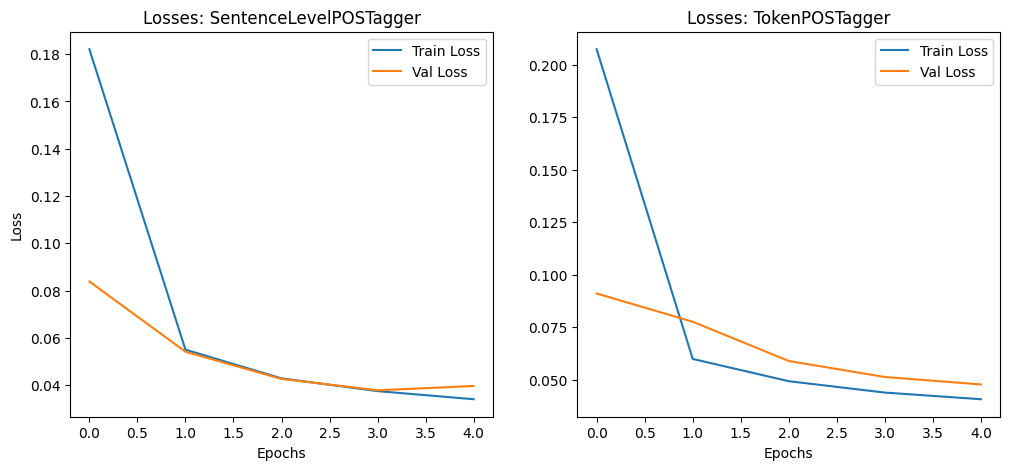


Оцінка контекстної моделі (Validation):
              precision    recall  f1-score   support

         ADJ       0.67      0.91      0.77      1258
         ADP       0.99      0.96      0.98      1157
         ADV       0.78      0.71      0.74       635
         AUX       0.76      0.91      0.83        82
       CCONJ       0.90      0.96      0.93       446
         DET       0.85      0.87      0.86       461
        INTJ       0.40      0.50      0.44         4
        NOUN       0.91      0.79      0.85      3263
         NUM       0.76      0.78      0.77       211
        PART       0.89      0.75      0.81       292
        PRON       0.90      0.78      0.84       404
       PROPN       0.64      0.70      0.67       406
       PUNCT       0.99      1.00      1.00      2423
       SCONJ       0.87      0.86      0.87       245
         SYM       0.50      0.12      0.20         8
        VERB       0.87      0.93      0.90      1224
           X       1.00      0.55      0

In [10]:
# Візуалізація втрат
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses_ctx, label='Train Loss')
plt.plot(val_losses_ctx, label='Val Loss')
plt.title('Losses: SentenceLevelPOSTagger')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses_sim, label='Train Loss')
plt.plot(val_losses_sim, label='Val Loss')
plt.title('Losses: TokenPOSTagger')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Оцінка
print("\nОцінка контекстної моделі (Validation):")
evaluate_model(context_model, val_loader, pos_vocab, device)

print("\nОцінка простої моделі (Validation):")
evaluate_model(simple_model, val_loader, pos_vocab, device)

Контекстна модель (SentenceLevelPOSTagger) швидше збігається і демонструє кращі (нижчі) кінцеві значення втрат на валідації (~0.04 проти ~0.05 у простої моделі). Це наочно підтверджує, що додавання знань про те, як слова взаємодіють між собою в реченні , дозволяє моделі працювати точніше.

Тестування моделей на складних реченнях (Омонімія)

In [11]:
# Клас POSTagger та тестування омонімії
class POSTagger:
    def __init__(self, model, char2id, id2label, max_sent_len, max_token_len): # Виправлено __init__ [cite: 406]
        self.model = model
        self.char2id = char2id
        self.id2label = id2label
        self.max_sent_len = max_sent_len
        self.max_token_len = max_token_len

    def tokenize_corpus(self, sentences, min_token_size=1):
        tokenized_corpus = []
        for sentence in sentences:
            tokens = [token for token in sentence.split() if len(token) >= min_token_size]
            tokenized_corpus.append(tokens)
        return tokenized_corpus

    def __call__(self, sentences, min_token_size=1, device="cpu"): # Виправлено __call__ [cite: 417]
        tokenized_corpus = self.tokenize_corpus(sentences, min_token_size=min_token_size)
        inputs = torch.zeros(len(sentences), self.max_sent_len, self.max_token_len + 2, dtype=torch.long)

        for sent_i, sentence in enumerate(tokenized_corpus):
            for token_i, token in enumerate(sentence):
                for char_i, char in enumerate(token):
                    if char_i + 1 < self.max_token_len + 2:
                        inputs[sent_i, token_i, char_i + 1] = self.char2id.get(char, 0)

        inputs = inputs.to(device)
        self.model.eval()
        with torch.no_grad():
            logits = self.model(inputs)
            predicted_classes = torch.argmax(logits, dim=-1)

        result = []
        for sent_i, sentence in enumerate(tokenized_corpus):
            sentence_result = []
            for token_i, token in enumerate(sentence):
                tag_id = predicted_classes[sent_i, token_i].item()
                tag_label = self.id2label.get(tag_id, "<UNK>")
                sentence_result.append((token, tag_label))
            result.append(sentence_result)
        return result

# Складні речення для перевірки омонімії [cite: 514-518]
test_sentences = [
    "Мама мила раму.",
    "У ванній було мило.",
    "Сорок сорок сиділи на даху.",
    "Голка куєште цвяхи, боєць і кудрявчить бокренка."
]

id2label = {v: k for k, v in pos_vocab.items()}

context_tagger = POSTagger(context_model, char_vocab, id2label, max_sentence_length, max_token_length)
simple_tagger = POSTagger(simple_model, char_vocab, id2label, max_sentence_length, max_token_length)

print("=== Проста модель (TokenPOSTagger) ===")
for sent_res in simple_tagger(test_sentences, device=device):
    print(" ".join(f"{t}_{tag}" for t, tag in sent_res))

print("\n=== Контекстна модель (SentenceLevelPOSTagger) ===")
for sent_res in context_tagger(test_sentences, device=device):
    print(" ".join(f"{t}_{tag}" for t, tag in sent_res))

=== Проста модель (TokenPOSTagger) ===
Мама_PROPN мила_VERB раму._VERB
У_ADP ванній_ADJ було_AUX мило._VERB
Сорок_NOUN сорок_NOUN сиділи_VERB на_ADP даху._VERB
Голка_PROPN куєште_VERB цвяхи,_NOUN боєць_NOUN і_CCONJ кудрявчить_VERB бокренка._NOUN

=== Контекстна модель (SentenceLevelPOSTagger) ===
Мама_PROPN мила_VERB раму._ADJ
У_ADP ванній_ADJ було_AUX мило._NOUN
Сорок_NOUN сорок_NOUN сиділи_VERB на_ADP даху._NOUN
Голка_PROPN куєште_VERB цвяхи,_ADJ боєць_NOUN і_CCONJ кудрявчить_VERB бокренка._ADJ


Проведене тестування на реальних та штучно ускладнених реченнях дозволило наочно порівняти роботу двох архітектур: базової моделі на рівні токенів (TokenPOSTagger) та моделі з урахуванням контексту (SentenceLevelPOSTagger) . Результати повністю підтверджують теоретичну гіпотезу про те, що для якісного POS-тегування аналізу лише морфології слова недостатньо .Мову дійсно можна порівняти з грою в пазли: щоб зрозуміти, куди вставити шматочок (слово), потрібно бачити загальну картину (речення) .

1. Розв'язання проблеми частиномовної омонімії
Основною перевагою контекстної моделі є її здатність вирішувати випадки частиномовної омонімії — явища, коли граматична роль незмінного за формою слова залежить від його оточення .Проста модель (TokenPOSTagger) виявилася вразливою до таких слів. Наприклад, у реченні «У ванній було мило.» вона класифікувала слово «мило.» як дієслово (VERB), спираючись лише на його форму (закінчення -о, типове для дієслів минулого часу середнього роду) . Вона працює як аналітик, що розглядає слова ізольовано.Контекстна модель (SentenceLevelPOSTagger) завдяки модулю context_backbone проаналізувала зв'язки між токенами . Врахувавши наявність локативу «У ванній» та допоміжного дієслова «було», вона безпомилково визначила «мило.» як іменник (NOUN) . Це доводить, що модель успішно комбінує локальні патерни символів із глобальним контекстом .

2. Аналіз типових помилок простої моделіПроста модель частіше робить помилки на словах, які:Мають нетипові для своєї частини мови суфікси чи закінчення.Є незмінюваними формами, що збігаються з іншими частинами мови.
Відсутність Context Backbone призводить до того, що модель не здатна скоригувати свій прогноз за допомогою синтаксичних підказок від сусідніх слів (наприклад, підмета чи прийменника).

3. Вплив якості токенізації на результати (Проблема знаків пунктуації)
Тестування виявило важливий побічний ефект: використання примітивної токенізації через метод .split() призвело до того, що знаки пунктуації (крапки, коми) «приклеїлися» до слів (наприклад, «раму.», «даху.») .Для простої моделі це стало катастрофою: символ крапки наприкінці слова повністю спотворив його морфологічний профіль на рівні символів, через що вона передбачила іменники «раму.» та «даху.» як дієслова (VERB).Контекстна модель виявилася значно стійкішою до цього шуму. Хоча крапка також заважала її символьному аналізатору (single_token_backbone), глобальний контекст допоміг частково виправити ситуацію (наприклад, «даху.» було правильно класифіковано як NOUN).

4. Межі можливостей обох моделей (Складні крайові випадки)
У фразі «Сорок сорок сиділи на даху.» обидві моделі передбачили обидва слова «сорок» як іменники (NOUN). Ідеологічно, контекстна модель мала б зрозуміти, що перше слово є числівником . Те, що вона цього не зробила, свідчить про те, що хоч архітектура і враховує контекст, її фінальні рішення сильно залежать від частотності подібних паттернів у навчальному датасеті. Якщо в тренувальній вибірці слово «сорок» зустрічалося переважно як іменник або не було подібних синтаксичних конструкцій, навіть контекстна мережа може схибити.

**Контрольні питання**

*1.	Що таке частиномовна омонімія? Наведіть приклади.*

Це явище, коли слово залишається незмінним за формою, але його значення та граматична роль повністю змінюються залежно від контексту. Приклад: "мило" (дієслово: "мама мила") та "мило" (іменник: "запашне мило").


*2.	Чим модель SentenceLevelPOSTagger відрізняється від моделі, що аналізує лише токени?*

Токенна модель аналізує структуру кожного слова ізольовано. SentenceLevelPOSTagger має двоетапний підхід: рівень символів (аналізує саме слово) та рівень контексту (аналізує зв'язки між токенами в реченні).

*3.	Яка роль backbone-архітектури (ConvResNet) у моделі?*

У моделі SentenceLevelPOSTagger архітектура ConvResNet є базовим будівельним блоком (backbone), який використовується для вилучення ознак на двох різних етапах аналізу:На рівні символів (single_token_backbone): Вона аналізує структуру кожного окремого токена на рівні символів. Використання згорткових шарів із глибокими резидуальними (ResNet) з'єднаннями дозволяє моделі ефективно вивчати складні морфологічні патерни слова, такі як корені, суфікси чи закінчення.На рівні контексту (context_backbone): Вона обробляє контекстні залежності між токенами в межах усього речення. Згорткова архітектура моделює послідовність слів, допомагаючи моделі "побачити", як сусідні токени взаємодіють між собою.Чому саме ResNet? Наявність ResNet-з'єднань (x = x + out у коді)  дозволяє будувати глибші мережі, уникаючи проблеми затухання градієнтів під час навчання. Інформація може безперешкодно проходити крізь шари, що пришвидшує і стабілізує процес оптимізації.

*4.	Чому під час навчання моделі ми використовуємо функцію втрат CrossEntropyLoss?*

Використання CrossEntropyLoss зумовлене самою природою задачі POS-тегування:Багатокласова класифікація: Визначення частини мови — це класична задача багатокласової класифікації. Для кожного слова (токена) модель повинна вибрати одну правильну категорію (тег) із заздалегідь відомого словника частин мови.Робота з логітами: На останньому шарі модель генерує так звані логіти (сирі числові оцінки) для кожної можливої мітки. CrossEntropyLoss бере ці логіти, математично перетворює їх на ймовірності (через вбудований Softmax) і порівнює з реальними мітками (правильними відповідями з датасету).Функція втрат штрафує модель тим сильніше, чим більша розбіжність між передбаченим розподілом і реальним. А вже під час тестування (коли ми не рахуємо втрати) з цих логітів просто обирається тег із максимальним значенням (torch.argmax).

*5.	Що означає використання torch.nn.AdaptiveMaxPool1d у моделі?*
Цей шар пулінгу зменшує розмірність, агрегуючи інформацію всередині кожного токена, і дозволяє динамічно обробляти токени різної довжини, зводячи їх до вектора фіксованої довжини.
